# ⚡ 0. Enable GPU (Kaggle)

In [1]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-04-15 03:22:25.153055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776223345.344017      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776223345.402727      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776223345.861236      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776223345.861279      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776223345.861282      55 computation_placer.cc:177] computation placer alr

Num GPUs Available: 2


# ⚡ 1. Mixed Precision (BOOST GPU SPEED 🚀)

In [2]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# 📦 2. Load PlantVillage Dataset (AUTO SPLIT)

In [3]:
DATA_DIR_PV = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

IMG_SIZE = 224
BATCH_SIZE = 16

train_pv = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR_PV,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_pv = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR_PV,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_pv.class_names
NUM_CLASSES = len(class_names)
print(NUM_CLASSES,class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


I0000 00:00:1776223380.868229      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776223380.874137      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
15 ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


# ⚡ 3. Optimize Data Pipeline (IMPORTANT FOR GPU)

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_pv = train_pv.cache().shuffle(1000).prefetch(AUTOTUNE)
val_pv = val_pv.cache().prefetch(AUTOTUNE)

print("Done Autotune!")

Done Autotune!


# 🧠 4. Data Augmentation (GPU friendly)

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
])
print("Done Augmentation!")

Done Augmentation!


# 🧠 5. Build EfficientNetB4

In [6]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models

base_model = EfficientNetB4(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

print("Done Basic Build of EfficientNet B4!")

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Done Basic Build of EfficientNet B4!


# 🔗 6. Custom Head

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input

# Apply data augmentation
x = data_augmentation(base_model.input)

# EfficientNet preprocessing
x = preprocess_input(x)

# Pass through base model
x = base_model(x, training=False)

# Custom classifier head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output layer
output = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

# Final model
model = models.Model(inputs=base_model.input, outputs=output)

print("Done Custom Build with EfficientNet-B4!")

Done Custom Build with EfficientNet-B4!


# ⚙️ 7. Compile (GPU optimized)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Done Compiling!")

Done Compiling!


# 🚀 8. Train on PlantVillage

In [9]:
history_pv = model.fit(
    train_pv,
    validation_data=val_pv,
    epochs=10
)

Epoch 1/10


I0000 00:00:1776223446.765040     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 209s 127ms/step - accuracy: 0.4652 - loss: 1.7857 - val_accuracy: 0.8299 - val_loss: 0.5492
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.7555 - loss: 0.7633 - val_accuracy: 0.8699 - val_loss: 0.4075
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.8113 - loss: 0.5883 - val_accuracy: 0.8910 - val_loss: 0.3381
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.8344 - loss: 0.5062 - val_accuracy: 0.9072 - val_loss: 0.2871
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.8484 - loss: 0.4509 - val_accuracy: 0.9038 - val_loss: 0.2876
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 103ms/step - accuracy: 0.8663 - loss: 0.4073 - val_accuracy: 0.9183 - val_loss: 0.2463
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.8726 - loss: 0.3869 - val_accuracy: 0.9234 - val_loss: 0.2338
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 108s 104ms/step - accuracy: 0.8

## 💾 Save Model

In [10]:
model.save("EfficientNet_B4.keras")

# 9. Scores

## Predictions

In [11]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_pv:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

## Classification Report (Precision, Recall, F1)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.98      0.97       200
                     Pepper__bell___healthy       0.97      0.99      0.98       302
                      Potato___Early_blight       0.99      1.00      0.99       189
                       Potato___Late_blight       0.93      0.97      0.95       188
                           Potato___healthy       0.96      0.81      0.88        31
                      Tomato_Bacterial_spot       0.95      0.95      0.95       441
                        Tomato_Early_blight       0.91      0.73      0.81       191
                         Tomato_Late_blight       0.93      0.91      0.92       341
                           Tomato_Leaf_Mold       0.98      0.88      0.93       185
                  Tomato_Septoria_leaf_spot       0.87      0.95      0.91       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.89      0.93

## Confusion Matrix

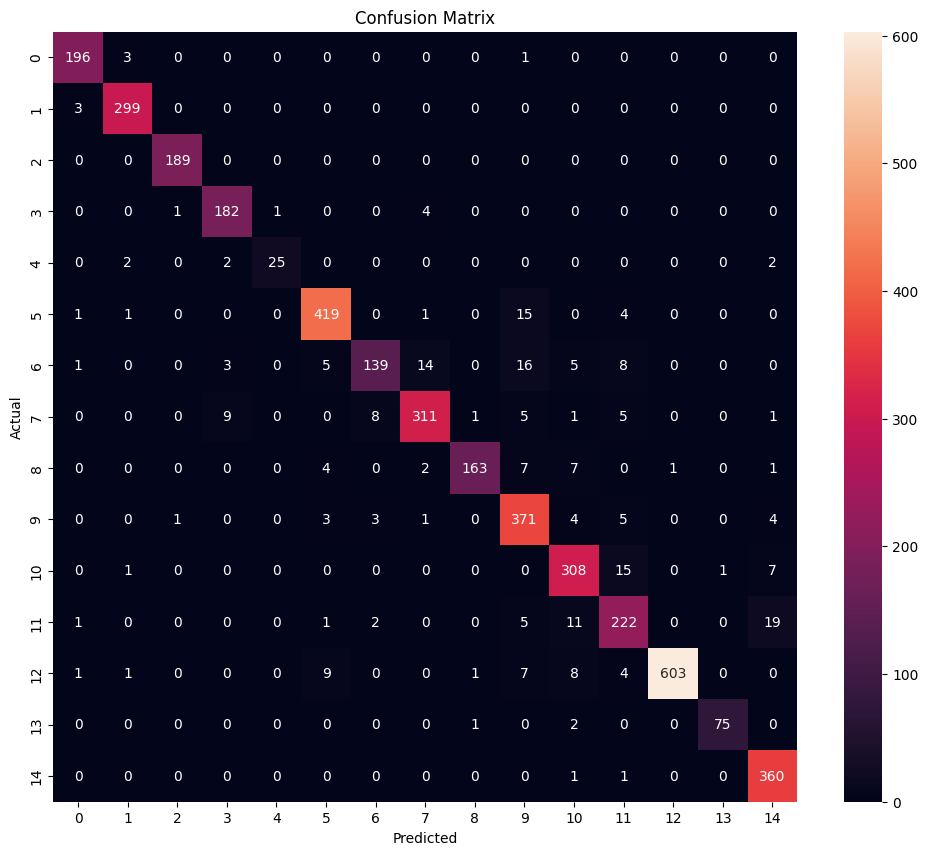

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Accuracy Graph

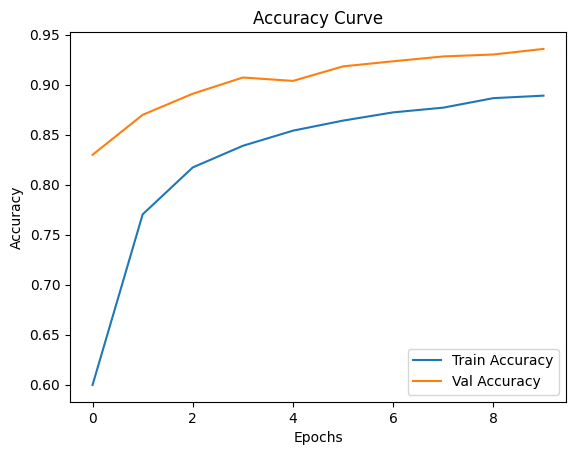

In [14]:
plt.figure()
plt.plot(history_pv.history['accuracy'], label='Train Accuracy')
plt.plot(history_pv.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

## Loss Graph

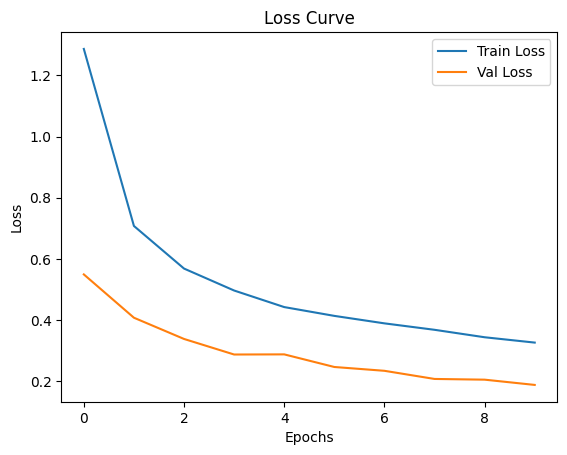

In [15]:
plt.figure()
plt.plot(history_pv.history['loss'], label='Train Loss')
plt.plot(history_pv.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## Per-Class Accuracy

In [16]:
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report).transpose()
print(df)

                                             precision    recall  f1-score  \
Pepper__bell___Bacterial_spot                 0.965517  0.980000  0.972705   
Pepper__bell___healthy                        0.973941  0.990066  0.981938   
Potato___Early_blight                         0.989529  1.000000  0.994737   
Potato___Late_blight                          0.928571  0.968085  0.947917   
Potato___healthy                              0.961538  0.806452  0.877193   
Tomato_Bacterial_spot                         0.950113  0.950113  0.950113   
Tomato_Early_blight                           0.914474  0.727749  0.810496   
Tomato_Late_blight                            0.933934  0.912023  0.922849   
Tomato_Leaf_Mold                              0.981928  0.881081  0.928775   
Tomato_Septoria_leaf_spot                     0.868852  0.946429  0.905983   
Tomato_Spider_mites_Two_spotted_spider_mite   0.887608  0.927711  0.907216   
Tomato__Target_Spot                           0.840909  0.850575